# test workflow

In [1]:
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.data.full_ecg_ds import Full_ECG_DataSet

In [2]:
dataset_path = "./dataset/ptb_xl_test/"

database = pd.read_csv(dataset_path + "ptbxl_database.csv")
statements = pd.read_csv(dataset_path + "scp_statements.csv")
print(f"Dataset: {database.shape}\nStatements: {statements.shape}")

Dataset: (999, 28)
Statements: (71, 13)


In [3]:
database.head(2)

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr


In [4]:
import pandas as pd
import numpy as np
import wfdb
import ast
from sklearn.preprocessing import MultiLabelBinarizer

sampling_rate = 100
path = dataset_path
target = 'sex'
mode='train'

test_fold = 10
val_fold = 9




# =-=-=-=-=-=-=-=-= load data =-=-=-=-=-=-=-=-=
Y: pd.DataFrame = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id', na_values='-1')
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)


# =-=-=-=-=-=-=-=-= filtering data from NaN =-=-=-=-=-=-=-=-=
# ======== AGE ========
if target == 'age':
    Y = Y[Y['age'] != -1]
# ======== sex ========
if target == 'sex':
    Y = Y[Y['sex'] != -1]

# =-=-=-=-=-=-=-=-= data splitting based on mode =-=-=-=-=-=-=-=-=
if mode == 'train':
    Y = Y[~Y.strat_fold.isin([test_fold, val_fold])]
elif mode == 'val':
    Y = Y[Y.strat_fold == val_fold]
elif mode == 'test':
    Y = Y[Y.strat_fold == test_fold]
else:
    raise ValueError('Invalid mode (train|val|test)')

# # Load raw signal data
# =-=-=-=-=-=-=-=-= Loading time serieses =-=-=-=-=-=-=-=-=
if sampling_rate == 100:
    data = [wfdb.rdsamp(path+f) for f in Y.filename_lr]
else:
    data = [wfdb.rdsamp(path+f) for f in Y.filename_hr]
X = np.array([signal for signal, meta in data]).transpose((0,2,1))
# Load scp_statements.csv for diagnostic aggregation

# =-=-=-=-=-=-=-=-= load targets =-=-=-=-=-=-=-=-=
if target == "scp":
    Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))


    agg_df = agg_df[agg_df.diagnostic == 1]

    name_to_index = {v:i for i,v in enumerate(agg_df.diagnostic_class.unique())}
    labels = []
    for codes in Y.scp_codes:
        tmp = []
        for key, value in codes.items():
            if (key in agg_df.index) and (value > 0.5):
                tmp.append(name_to_index[agg_df.loc[key].diagnostic_class])
        labels.append(tmp)
    # transform labels to ONEHOT (doing classification)
    y = MultiLabelBinarizer().fit_transform(labels)
elif target == "sex":
    y = Y.sex.to_numpy().reshape(-1,1)
elif target == "age":
    y = Y.age.to_numpy().reshape(-1,1)

In [5]:
print(X.shape)
print(y.shape)

(732, 12, 1000)
(732, 1)


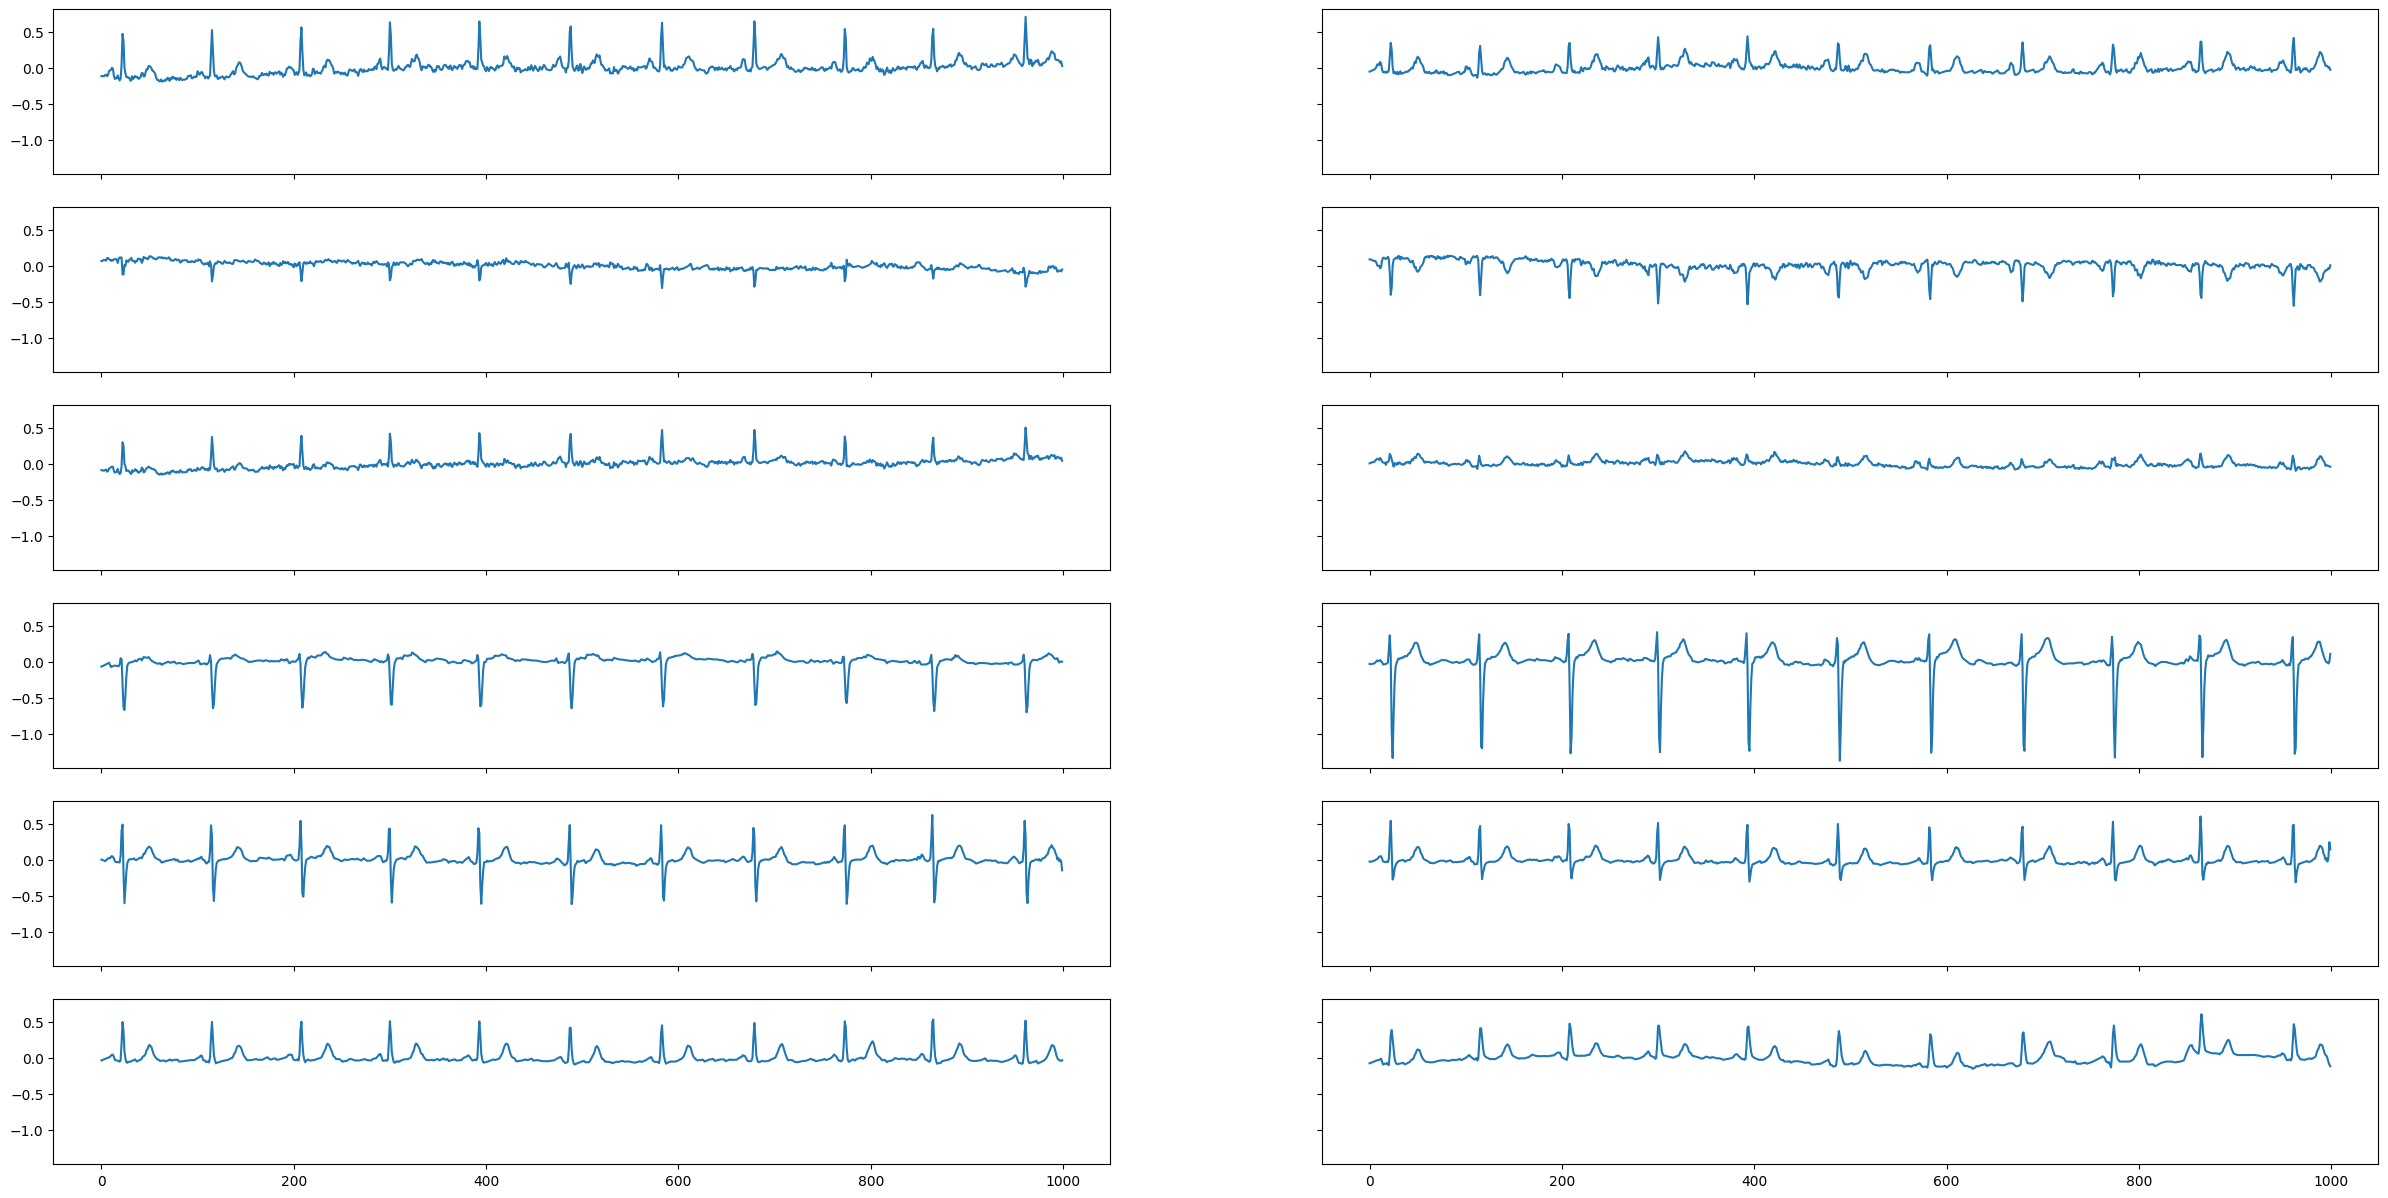

In [6]:
import matplotlib.pyplot as plt
sample = X[0]
fig, axs = plt.subplots(6, 2, figsize=(30, 15), sharex=True, sharey=True)
for i,ax in enumerate(axs.flat):
    ax.plot(sample[i])

[101 190 281 371 454 533 625 720 809 894 978]
(10, 12, 60)
Znaleziono 10 uderzeń serca.


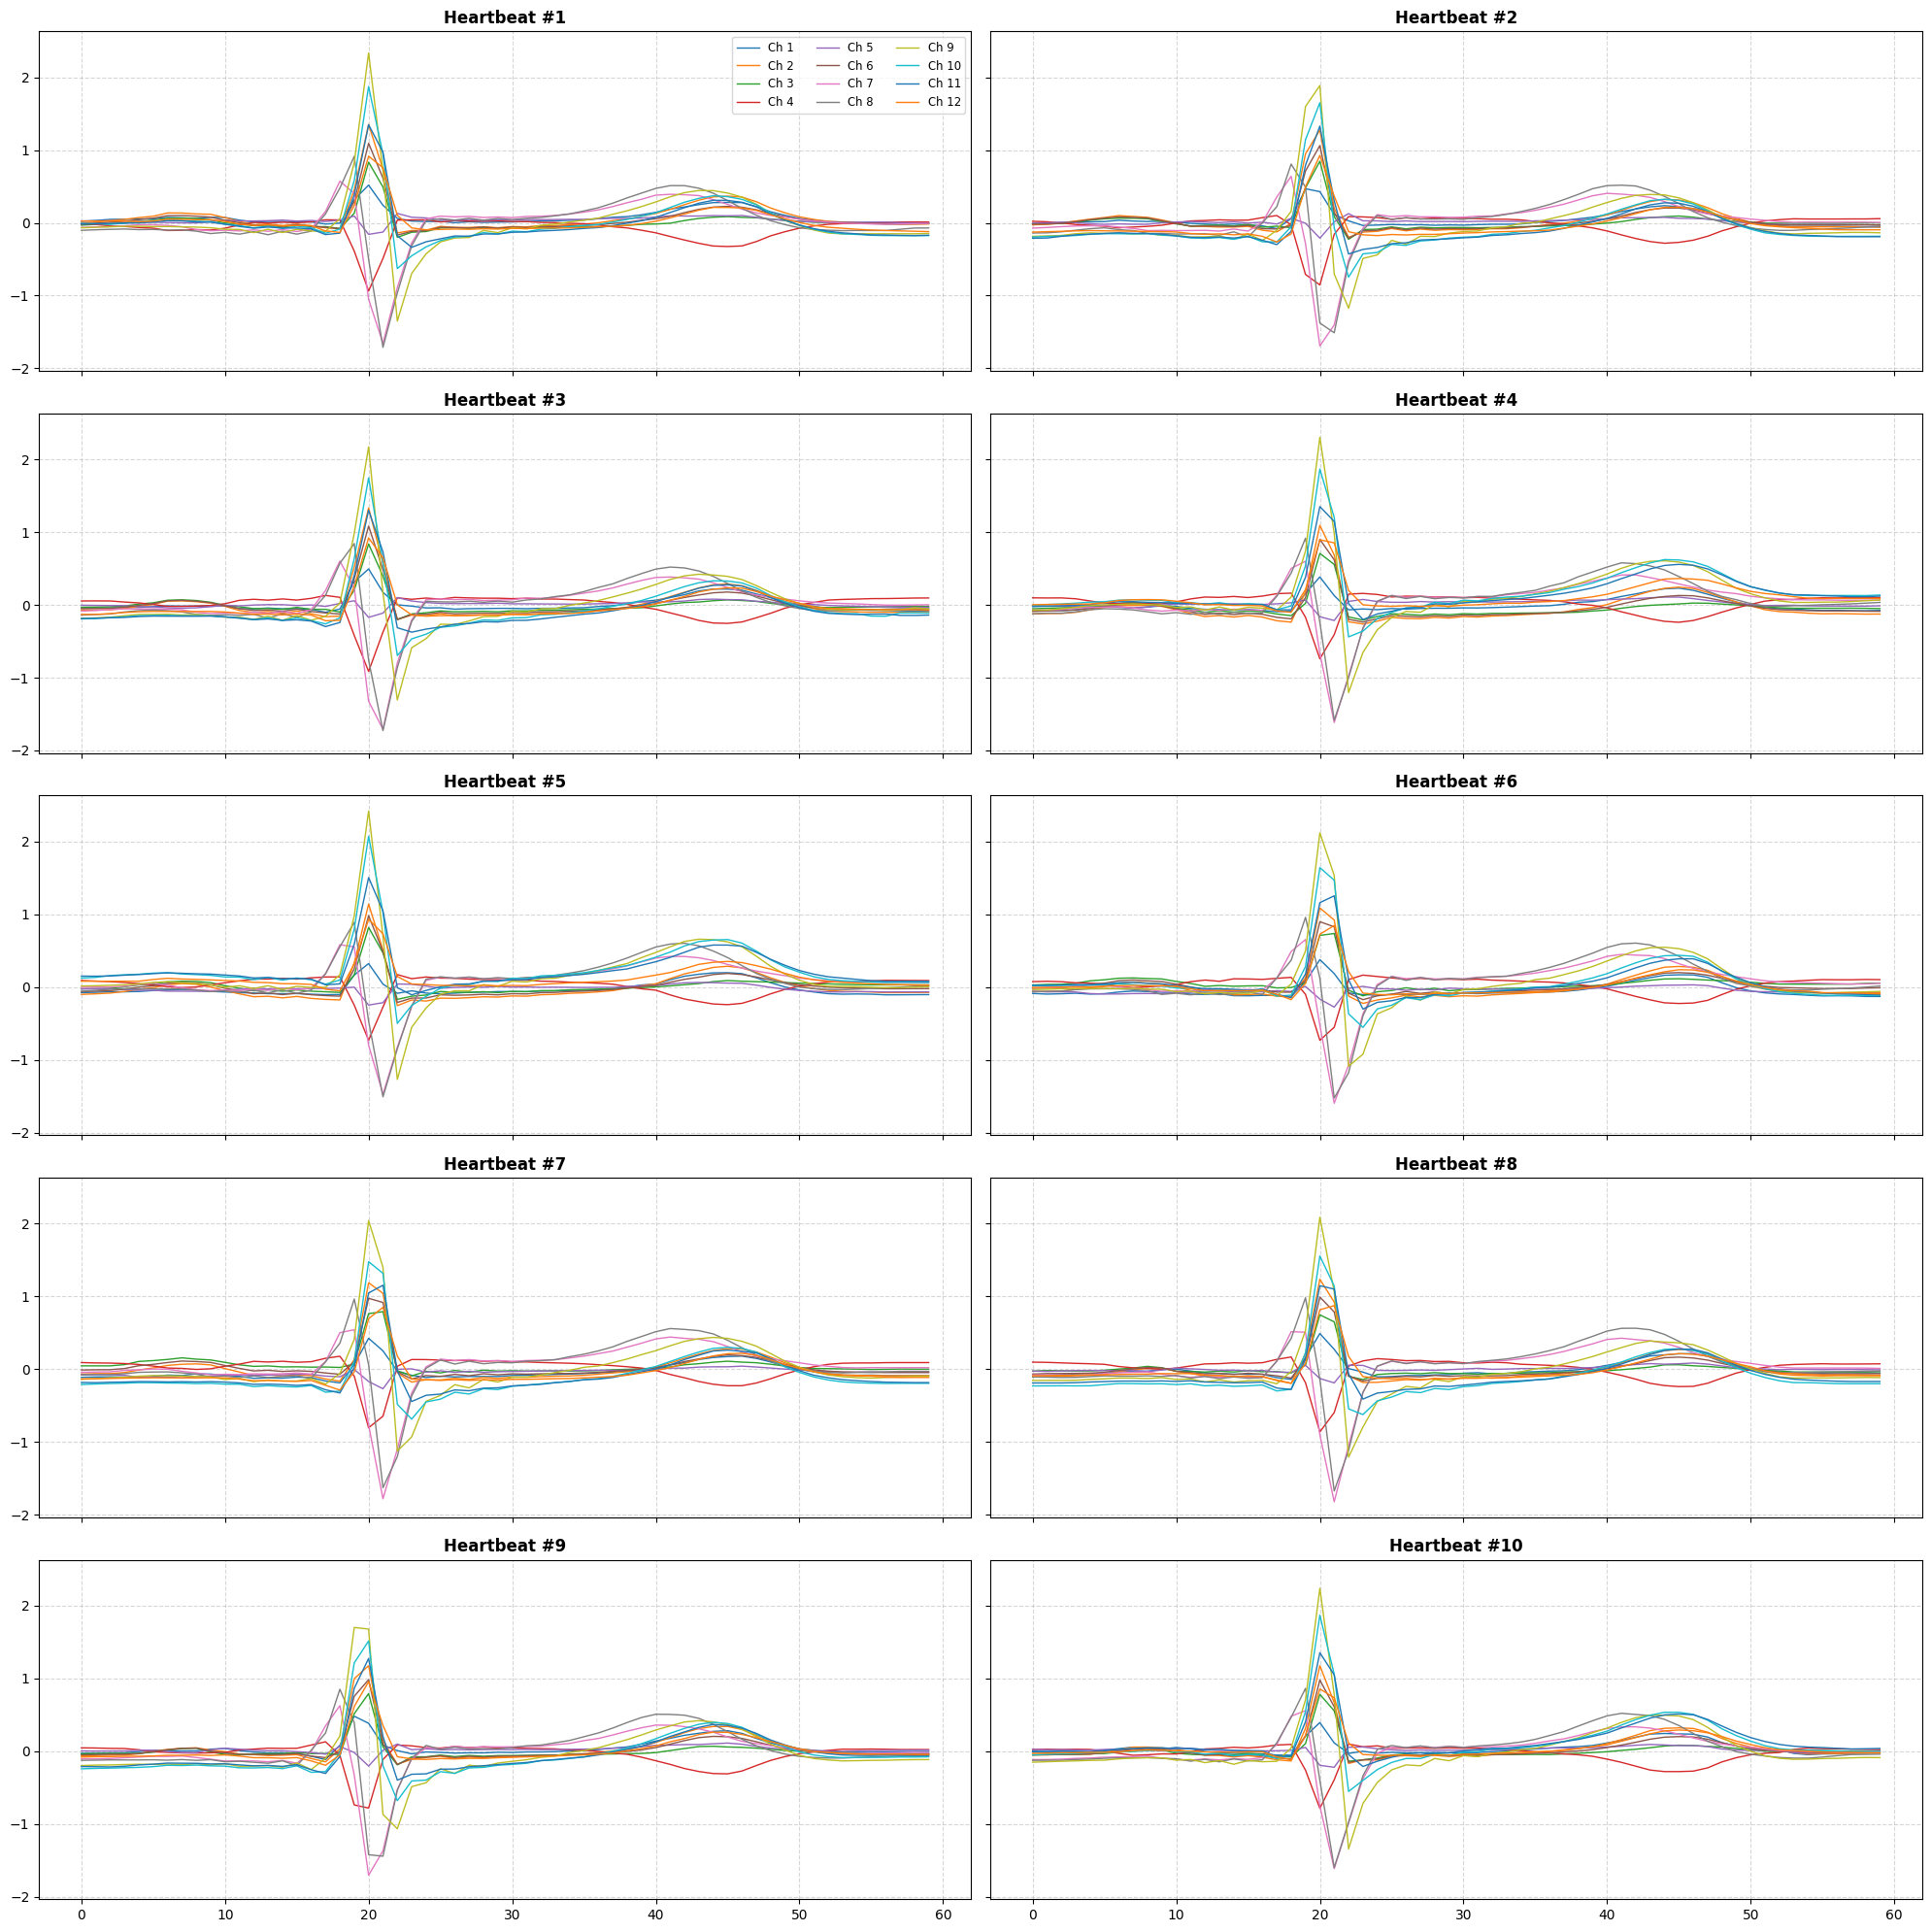

In [17]:
import neurokit2 as nk

# 1. Przygotowanie parametrów
# (Załóżmy, że signal to tablica numpy o kształcie (1000, 12) z rdsamp)
rand_index = np.random.randint(0,len(X))
signal = np.transpose(X,(0,2,1))[rand_index]

sampling_rate = 100
lead_index = 1  # Zazwyczaj II odprowadzenie jest najlepsze do detekcji pików
single_lead = signal[:, lead_index]

# 2. Detekcja uderzeń (R-peaks)
# nk.ecg_process robi wszystko: filtruje szum i znajduje piki
signals, info = nk.ecg_process(single_lead, sampling_rate=sampling_rate)
r_peaks = info["ECG_R_Peaks"] # Indeksy, w których występuje uderzenie

print(r_peaks)

# 3. Definiowanie okna (ile próbek przed i po piku wyciąć)
# Przykładowo: 200ms przed pikiem i 400ms po piku
pre_samples = int(0.2 * sampling_rate)
post_samples = int(0.4 * sampling_rate)

heartbeats = []

for peak in r_peaks:
    # Sprawdzamy, czy okno nie wychodzi poza zakres pliku
    if peak - pre_samples > 0 and peak + post_samples < len(single_lead):
        # Wycinamy fragment ze wszystkich 12 kanałów jednocześnie!
        segment = signal[peak - pre_samples : peak + post_samples, :]
        heartbeats.append(segment)

heartbeats = np.array(heartbeats).transpose((0,2,1))

print(heartbeats.shape)
print(f"Znaleziono {len(heartbeats)} uderzeń serca.")








# -=-=-=-==-=-= PLOTTING -==-=-=--=-=-=-=-=-
import matplotlib.pyplot as plt

n_beats = len(heartbeats)
cols = 2
rows = (n_beats + 1) // 2  # Oblicza liczbę wierszy dla 2 kolumn

fig, axs = plt.subplots(rows, cols, figsize=(20, rows * 4), sharex=True, sharey=True)
axs = axs.flatten()  # Spłaszczamy, żeby łatwo iterować (nawet jeśli jest 1 subplot)

for i in range(n_beats):
    ax = axs[i]
    beat = heartbeats[i]  # Kształt: (12, próbki)

    # Rysujemy każdy z 12 kanałów
    for ch_idx in range(12):
        ax.plot(beat[ch_idx, :], linewidth=1, label=f"Ch {ch_idx+1}")

    ax.set_title(f"Heartbeat #{i+1}", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

    # Opcjonalnie: dodaj legendę tylko do pierwszego wykresu, żeby nie śmiecić
    if i == 0:
        ax.legend(loc='upper right', fontsize='small', ncol=3)

# Usuwamy puste osie, jeśli liczba uderzeń jest nieparzysta
for j in range(n_beats, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [ ]:
# from src.data import Full_ECG_DataSet
# from torch.utils.data import DataLoader
#
# ds = Full_ECG_DataSet(path = dataset_path)
# loader = DataLoader(ds, batch_size=64, shuffle=True)
#
# for X, y in loader:
#     print(X.shape)